# Scientific diagnostics — Ridge25 five-year workflow

Notebook exploratorio para reconstruir **figuras adicionales** a partir de los productos vigentes del pipeline `five-year-ridge25-exact-overlap-v1`.

Principios:

- solo **lee** `runs/`, `diagnostics/`, `master/` y `rasters/` del workspace externo;
- no vuelve a entrenar, no cambia el modelo, no modifica AOA ni reconciliación;
- no usa resultados históricos como insumos;
- las comparaciones con campo se presentan como **comparación de ET derivada en campo**, no como validación independiente a 20 m;
- los efectos de familias de predictores son diagnósticos predictivos en la misma población y **no implican causalidad**.

Las figuras se guardan inicialmente con prefijo `Dxx`, no `Fxx`, para revisarlas antes de incorporarlas al contrato final de figuras del manuscrito.

In [12]:
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------------

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "pyproject.toml").is_file():
        return cwd
    if cwd.name == "notebooks" and (cwd.parent / "pyproject.toml").is_file():
        return cwd.parent
    raise RuntimeError("Run this notebook from the repository root or notebooks/ directory.")


REPO_ROOT = resolve_repo_root()

# Optional portable override for another PC:
#   PowerShell: $env:ET_FUNDACION_WORKSPACE = "D:\\...\\ET_fundacion_workspace\\current"
workspace_env = os.environ.get("ET_FUNDACION_WORKSPACE")
WORKSPACE = (
    Path(workspace_env).expanduser().resolve()
    if workspace_env
    else (REPO_ROOT.parent / "ET_fundacion_workspace" / "current").resolve()
)

RUNS_ROOT = WORKSPACE / "runs"
DIAGNOSTICS_ROOT = WORKSPACE / "diagnostics"
RASTERS_ROOT = WORKSPACE / "rasters"

# None = use the most recent 2020_2024 run available in the workspace.
RUN_ID = None

if RUN_ID is None:
    candidates = sorted(p for p in RUNS_ROOT.glob("*_2020_2024") if p.is_dir())
    if not candidates:
        raise FileNotFoundError(f"No 2020_2024 run found under {RUNS_ROOT}")
    RUN_DIR = candidates[-1]
else:
    RUN_DIR = RUNS_ROOT / RUN_ID

FIGURE_DIR = DIAGNOSTICS_ROOT / "scientific_figures_v1"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Repository:", REPO_ROOT)
print("Workspace:", WORKSPACE)
print("Run:", RUN_DIR.name)
print("Figure output:", FIGURE_DIR)


Repository: E:\1SIG22\Varios\github\git_github\26-et-downscaling-fundacion
Workspace: E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current
Run: 20260905T032319Z_2020_2024
Figure output: E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\scientific_figures_v1


In [13]:
# -----------------------------------------------------------------------------
# Helpers and input discovery
# -----------------------------------------------------------------------------

def find_one(root: Path, filename: str) -> Path | None:
    matches = sorted(root.rglob(filename)) if root.exists() else []
    if not matches:
        return None
    if len(matches) > 1:
        print(f"WARNING: multiple matches for {filename}; using {matches[0]}")
    return matches[0]


def require(path: Path | None, label: str) -> Path:
    if path is None or not path.is_file():
        raise FileNotFoundError(f"Missing {label}: {path}")
    return path


def save_figure(fig, filename: str) -> Path:
    path = FIGURE_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", path)
    return path


def regression_metrics(observed, predicted):
    observed = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    valid = np.isfinite(observed) & np.isfinite(predicted)
    observed = observed[valid]
    predicted = predicted[valid]
    if len(observed) == 0:
        return {"n": 0, "RMSE": np.nan, "MAE": np.nan, "BIAS": np.nan, "R2": np.nan}
    error = predicted - observed
    sse = float(np.sum(error ** 2))
    sst = float(np.sum((observed - observed.mean()) ** 2))
    r2 = np.nan if sst <= 0 else 1.0 - sse / sst
    return {
        "n": int(len(observed)),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "MAE": float(np.mean(np.abs(error))),
        "BIAS": float(np.mean(error)),
        "R2": float(r2),
    }


tables = RUN_DIR / "tables"
SPATIAL_OOF = require(find_one(tables, "ridge25_spatial_oof.csv"), "spatial OOF table")
SPATIAL_FOLDS = require(find_one(tables, "ridge25_spatial_fold_metrics.csv"), "spatial fold table")
LOYO_FOLDS = require(find_one(tables, "ridge25_loyo_fold_metrics.csv"), "LOYO fold table")

FIELD_PAIRS = find_one(DIAGNOSTICS_ROOT, "field_ridge25_oof_pairs.csv")
AVAILABILITY_LADDER = find_one(DIAGNOSTICS_ROOT, "availability_ladder.csv")
FAMILY_EFFECTS = find_one(DIAGNOSTICS_ROOT, "family_same_population_effects.csv")
AGGREGATE_SENSITIVITY = find_one(DIAGNOSTICS_ROOT, "aggregate_metrics.csv")
RECON_STATIONS = find_one(DIAGNOSTICS_ROOT / "overlap_reconciliation", "stations_2022-04-07.csv")
RECON_SUMMARY = find_one(DIAGNOSTICS_ROOT / "overlap_reconciliation", "summary_2022-04-07.json")
FINAL_RASTER = find_one(RASTERS_ROOT / "2022-04-07", "ET_ridge25_exact_overlap_support90_tol001_v2_2022-04-07_20m.tif")

print("Core run tables: OK")
for label, path in {
    "field pairs": FIELD_PAIRS,
    "availability ladder": AVAILABILITY_LADDER,
    "family effects": FAMILY_EFFECTS,
    "aggregate sensitivity": AGGREGATE_SENSITIVITY,
    "reconciliation stations": RECON_STATIONS,
    "reconciliation summary": RECON_SUMMARY,
    "final raster": FINAL_RASTER,
}.items():
    print(f"{label:28s}: {path if path else 'NOT FOUND (optional figure will be skipped)'}")


Core run tables: OK
field pairs                 : E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\field_ridge25_oof_exact_overlap\field_ridge25_oof_pairs.csv
availability ladder         : E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\sensitivity\2020_2024\predictor_availability_ladder\availability_ladder.csv
family effects              : E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\sensitivity\2020_2024\predictor_availability_ladder\family_same_population_effects.csv
aggregate sensitivity       : E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\sensitivity\2020_2024\predictor_availability_ladder\aggregate_metrics.csv
reconciliation stations     : E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\overlap_reconciliation\stations_2022-04-07.csv
reconciliation summary      : E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\

## D01 — Fold-level stability of the final Ridge25 model

Complementa F17. En vez de mostrar solo las métricas agregadas, muestra la dispersión entre bloques espaciales y años LOYO. Esto permite detectar si el desempeño promedio está dominado por uno o pocos folds.

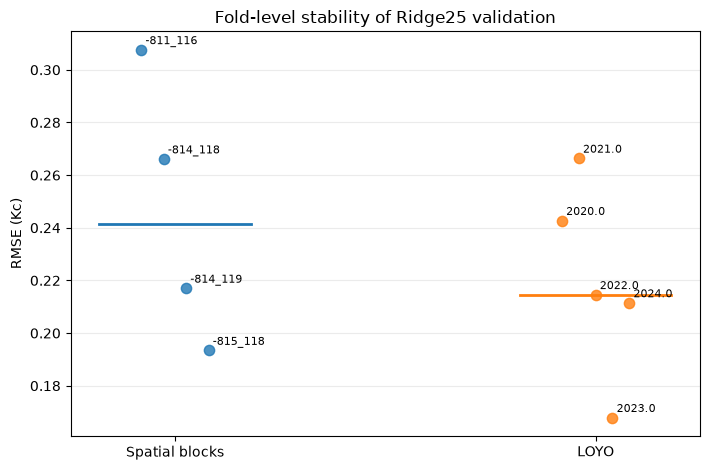

Saved: E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\scientific_figures_v1\D01_fold_level_rmse.png


WindowsPath('E:/1SIG22/Varios/github/git_github/ET_fundacion_workspace/current/diagnostics/scientific_figures_v1/D01_fold_level_rmse.png')

In [14]:
spatial_folds = pd.read_csv(SPATIAL_FOLDS)
loyo_folds = pd.read_csv(LOYO_FOLDS)

fig, ax = plt.subplots(figsize=(7.2, 4.8))

protocols = [
    ("Spatial blocks", spatial_folds, 0),
    ("LOYO", loyo_folds, 1),
]

for protocol, frame, xpos in protocols:
    y = frame["RMSE"].to_numpy(dtype=float)
    jitter = np.linspace(-0.08, 0.08, len(y)) if len(y) > 1 else np.array([0.0])
    ax.scatter(np.full(len(y), xpos) + jitter, y, s=55, alpha=0.8)
    median = float(np.nanmedian(y))
    ax.plot([xpos - 0.18, xpos + 0.18], [median, median], linewidth=2.0)
    for dx, (_, row) in zip(jitter, frame.iterrows()):
        ax.annotate(str(row.get("group", row.get("fold", ""))),
                    (xpos + dx, float(row["RMSE"])),
                    xytext=(3, 4), textcoords="offset points", fontsize=8)

ax.set_xticks([0, 1], ["Spatial blocks", "LOYO"])
ax.set_ylabel("RMSE (Kc)")
ax.set_title("Fold-level stability of Ridge25 validation")
ax.grid(axis="y", alpha=0.25)

save_figure(fig, "D01_fold_level_rmse.png")


## D02 — Spatial OOF error distribution by station

Complementa F19. Muestra la distribución y sesgo de los errores OOF por estación, no únicamente RMSE. Es útil para identificar heterogeneidad sistemática entre coberturas/sitios.

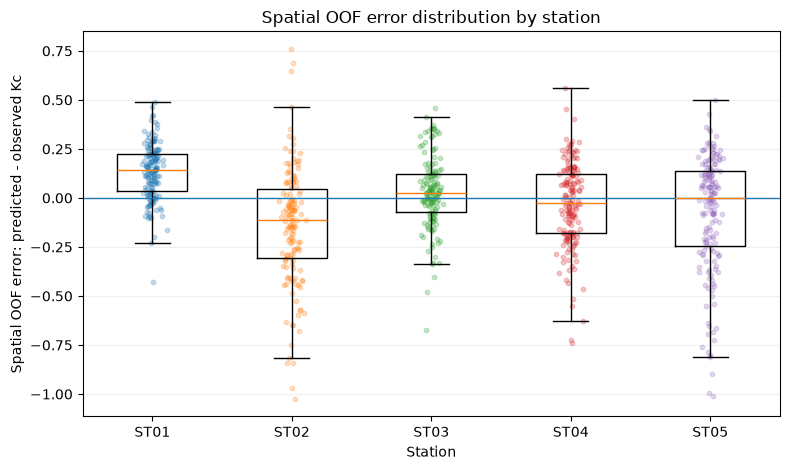

Saved: E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\scientific_figures_v1\D02_spatial_oof_error_by_station.png


WindowsPath('E:/1SIG22/Varios/github/git_github/ET_fundacion_workspace/current/diagnostics/scientific_figures_v1/D02_spatial_oof_error_by_station.png')

In [15]:
oof = pd.read_csv(SPATIAL_OOF, parse_dates=["period_start"])
stations = sorted(oof["station_id"].astype(str).unique())
series = [oof.loc[oof["station_id"].astype(str).eq(station), "error"].dropna().to_numpy() for station in stations]

fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.boxplot(series, tick_labels=stations, showfliers=False)

rng = np.random.default_rng(42)
for xpos, values in enumerate(series, start=1):
    x = xpos + rng.normal(0.0, 0.035, size=len(values))
    ax.scatter(x, values, s=10, alpha=0.25)

ax.axhline(0.0, linewidth=1.0)
ax.set_xlabel("Station")
ax.set_ylabel("Spatial OOF error: predicted - observed Kc")
ax.set_title("Spatial OOF error distribution by station")
ax.grid(axis="y", alpha=0.2)

save_figure(fig, "D02_spatial_oof_error_by_station.png")


## D03 — Field-derived ET compared with MODIS parent and downscaled OOF ET

Figura equivalente en propósito a F05/F20, usando **solo la evaluación exact-overlap vigente**.

La población principal se restringe a ST01–ST03 (Kc fijo). Esta figura **no se describe como validación independiente a 20 m**: el ET de campo es derivado y el producto fino conserva información MODIS mediante reconciliación.

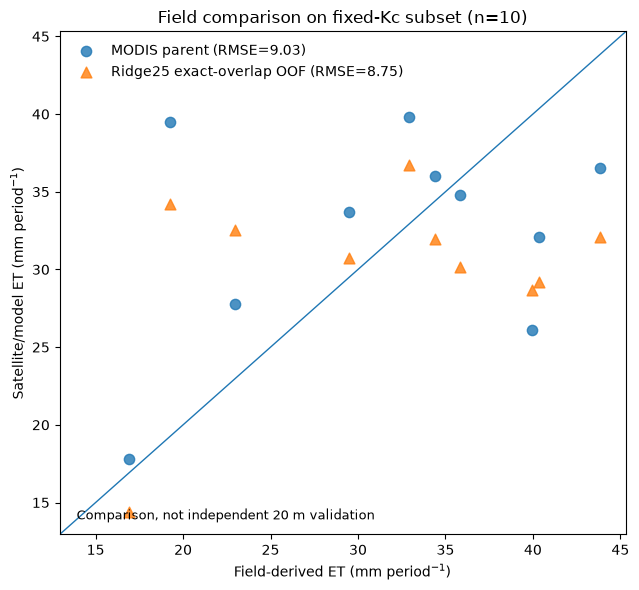

Saved: E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\scientific_figures_v1\D03_field_et_comparison_fixed_kc.png


,station_id,period_start,field_derived_et_mm_period,ET_MODIS_mm_period,ET_downscaled_oof_mm_period
1,ST01,2022-03-22,22.950000,27.799999,32.523265
2,ST01,2022-03-30,39.950000,26.100000,28.666478
11,ST02,2022-03-22,29.506819,33.700001,30.751355
12,ST02,2022-03-30,34.388400,36.000000,31.986947
13,ST02,2022-04-07,32.906413,39.799999,36.749604
16,ST02,2022-05-01,16.928296,17.799999,14.413966
18,ST02,2022-05-17,19.265520,39.500000,34.212319
23,ST03,2022-03-30,40.336787,32.099998,29.212158
24,ST03,2022-04-07,43.851396,36.500000,32.091576
29,ST03,2022-05-17,35.810839,34.799999,30.139174


In [16]:
if FIELD_PAIRS is None:
    print("SKIP D03: field_ridge25_oof_pairs.csv not found")
else:
    field = pd.read_csv(FIELD_PAIRS)
    field["station_id"] = field["station_id"].astype(str)
    main = field.loc[
        field["station_id"].isin(["ST01", "ST02", "ST03"])
        & field["field_derived_et_mm_period"].notna()
        & field["ET_MODIS_mm_period"].notna()
        & field["ET_downscaled_oof_mm_period"].notna()
    ].copy()

    if main.empty:
        print("SKIP D03: no published fixed-Kc field pairs found")
    else:
        observed = main["field_derived_et_mm_period"].to_numpy(dtype=float)
        modis = main["ET_MODIS_mm_period"].to_numpy(dtype=float)
        fine = main["ET_downscaled_oof_mm_period"].to_numpy(dtype=float)
        m_modis = regression_metrics(observed, modis)
        m_fine = regression_metrics(observed, fine)

        values = np.concatenate([observed, modis, fine])
        lower = float(np.nanmin(values))
        upper = float(np.nanmax(values))
        margin = 0.05 * max(upper - lower, 1.0)
        lower -= margin
        upper += margin

        fig, ax = plt.subplots(figsize=(6.5, 6.0))
        ax.scatter(observed, modis, marker="o", s=55, alpha=0.8,
                   label=f"MODIS parent (RMSE={m_modis['RMSE']:.2f})")
        ax.scatter(observed, fine, marker="^", s=60, alpha=0.8,
                   label=f"Ridge25 exact-overlap OOF (RMSE={m_fine['RMSE']:.2f})")
        ax.plot([lower, upper], [lower, upper], linewidth=1.0)
        ax.set_xlim(lower, upper)
        ax.set_ylim(lower, upper)
        ax.set_xlabel("Field-derived ET (mm period$^{-1}$)")
        ax.set_ylabel("Satellite/model ET (mm period$^{-1}$)")
        ax.set_title(f"Field comparison on fixed-Kc subset (n={len(main)})")
        ax.legend(frameon=False)
        ax.text(0.03, 0.03,
                "Comparison, not independent 20 m validation",
                transform=ax.transAxes, fontsize=9)

        save_figure(fig, "D03_field_et_comparison_fixed_kc.png")
        display(main[["station_id", "period_start", "field_derived_et_mm_period",
                      "ET_MODIS_mm_period", "ET_downscaled_oof_mm_period"]])


C:\Users\usrlabsis22\AppData\Local\Temp\ipykernel_8584\792527984.py:22: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


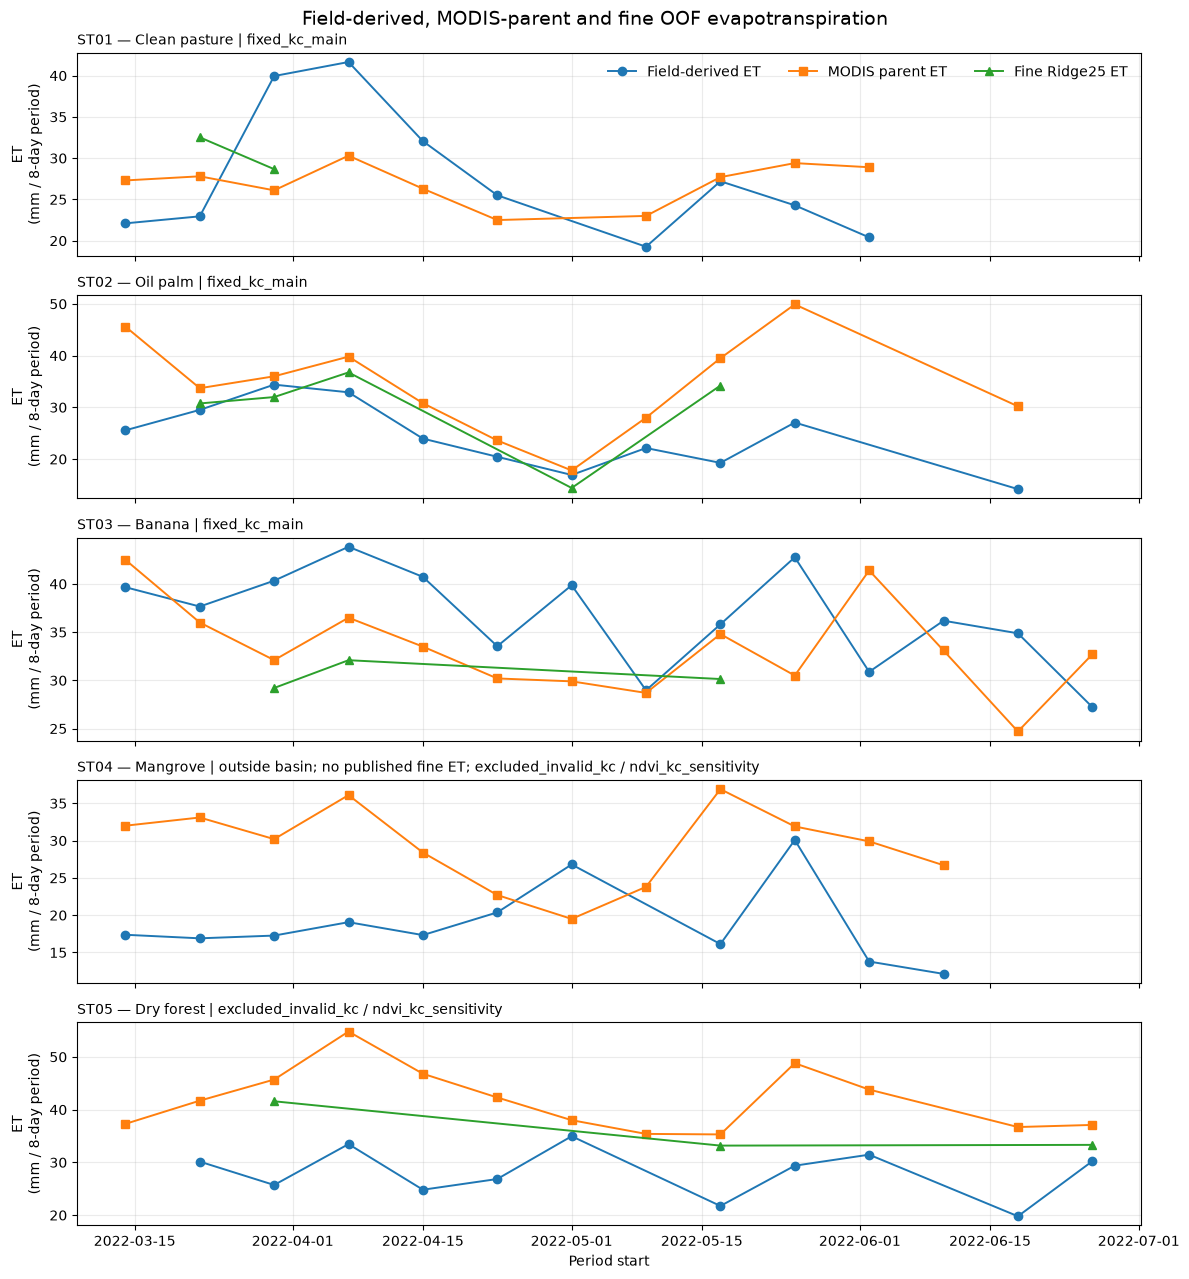

Saved: E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\scientific_figures_v1\D03b_field_modis_fine_timeseries_5stations.png


,station_id,station,n_field,n_modis,n_fine
0,ST01,Clean pasture,10,10,2
1,ST02,Oil palm,11,11,5
2,ST03,Banana,14,14,3
3,ST04,Mangrove,11,12,0
4,ST05,Dry forest,11,13,3


In [17]:
# D03b — Field-derived ET vs MODIS-parent ET vs fine Ridge25 ET across five stations

field_ts = pd.read_csv(FIELD_PAIRS, parse_dates=["period_start"])
field_ts["station_id"] = field_ts["station_id"].astype(str)

station_order = ["ST01", "ST02", "ST03", "ST04", "ST05"]

station_names = {
    "ST01": "Clean pasture",
    "ST02": "Oil palm",
    "ST03": "Banana",
    "ST04": "Mangrove",
    "ST05": "Dry forest",
}

fig, axes = plt.subplots(
    5,
    1,
    figsize=(12, 13),
    sharex=True,
    constrained_layout=True,
)

summary_rows = []

for ax, station_id in zip(axes, station_order):

    group = (
        field_ts.loc[field_ts["station_id"].eq(station_id)]
        .sort_values("period_start")
        .copy()
    )

    if group.empty:
        ax.text(
            0.5,
            0.5,
            "No records",
            transform=ax.transAxes,
            ha="center",
            va="center",
        )
        ax.set_title(station_id, loc="left")
        continue

    station_name = station_names.get(station_id, station_id)

    if "station" in group.columns and group["station"].notna().any():
        station_name = str(group["station"].dropna().iloc[0])

    field_mask = group["field_derived_et_mm_period"].notna()
    modis_mask = group["ET_MODIS_mm_period"].notna()
    fine_mask = group["ET_downscaled_oof_mm_period"].notna()

    # Field-derived ET
    ax.plot(
        group.loc[field_mask, "period_start"],
        group.loc[field_mask, "field_derived_et_mm_period"],
        marker="o",
        linewidth=1.4,
        label="Field-derived ET",
    )

    # Parent MODIS ET
    ax.plot(
        group.loc[modis_mask, "period_start"],
        group.loc[modis_mask, "ET_MODIS_mm_period"],
        marker="s",
        linewidth=1.4,
        label="MODIS parent ET",
    )

    # Fine OOF ET from the current Ridge25 + exact-overlap workflow
    ax.plot(
        group.loc[fine_mask, "period_start"],
        group.loc[fine_mask, "ET_downscaled_oof_mm_period"],
        marker="^",
        linewidth=1.4,
        label="Fine Ridge25 ET",
    )

    notes = []

    if "inside_basin" in group.columns:
        if not bool(group["inside_basin"].fillna(False).any()):
            notes.append("outside basin")

    if fine_mask.sum() == 0:
        notes.append("no published fine ET")

    if "analysis_role" in group.columns:
        roles = sorted(
            {
                str(value)
                for value in group["analysis_role"].dropna().unique()
                if str(value).strip()
            }
        )
        if roles:
            notes.append(" / ".join(roles))

    title = f"{station_id} — {station_name}"

    if notes:
        title += " | " + "; ".join(notes)

    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel("ET\n(mm / 8-day period)")
    ax.grid(alpha=0.25)

    summary_rows.append(
        {
            "station_id": station_id,
            "station": station_name,
            "n_field": int(field_mask.sum()),
            "n_modis": int(modis_mask.sum()),
            "n_fine": int(fine_mask.sum()),
        }
    )

axes[0].legend(
    frameon=False,
    ncol=3,
    loc="upper right",
)

axes[-1].set_xlabel("Period start")

fig.suptitle(
    "Field-derived, MODIS-parent and fine OOF evapotranspiration",
    fontsize=14,
)

save_figure(
    fig,
    "D03b_field_modis_fine_timeseries_5stations.png",
)

plt.show()

pd.DataFrame(summary_rows)

## D04 — Predictor availability ladder

Equivalente en propósito a F21. Muestra cómo cambia el tamaño muestral cuando se retiran bloques limitados por disponibilidad. La figura es **descriptiva de disponibilidad**, no un ranking de importancia predictiva.

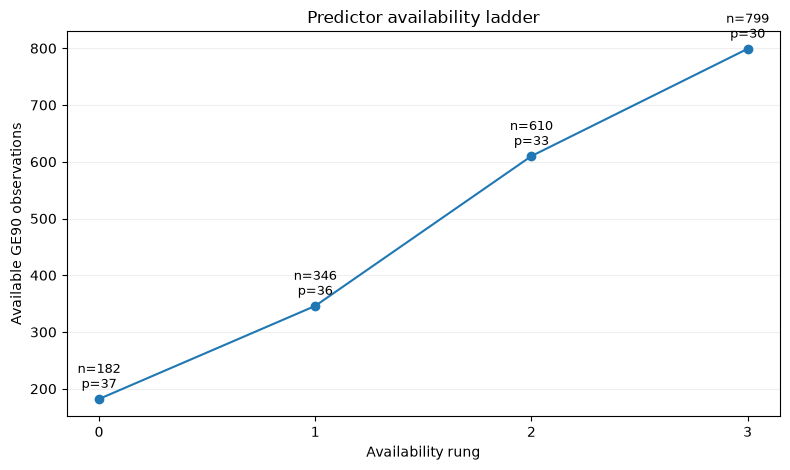

Saved: E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\scientific_figures_v1\D04_predictor_availability_ladder.png


,rung,n,predictors,change
0,0,182,37,All admissible candidates
1,1,346,36,LANDSAT_LST
2,2,610,33,S1_R142
3,3,799,30,S1_R077


In [6]:
if AVAILABILITY_LADDER is None:
    print("SKIP D04: availability_ladder.csv not found")
else:
    ladder = pd.read_csv(AVAILABILITY_LADDER).sort_values("rung")

    first = ladder.iloc[0]
    rows = [{
        "rung": 0,
        "n": int(first["n_before"]),
        "predictors": int(first["predictors_before"]),
        "change": "All admissible candidates",
    }]
    for _, row in ladder.iterrows():
        rows.append({
            "rung": int(row["rung"]),
            "n": int(row["n_after"]),
            "predictors": int(row["predictors_after"]),
            "change": str(row["removed_predictor_or_block"]),
        })
    ladder_plot = pd.DataFrame(rows).drop_duplicates("rung").sort_values("rung")

    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    ax.plot(ladder_plot["rung"], ladder_plot["n"], marker="o", linewidth=1.5)
    for _, row in ladder_plot.iterrows():
        ax.annotate(f"n={int(row['n'])}\np={int(row['predictors'])}",
                    (row["rung"], row["n"]), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=9)
    ax.set_xticks(ladder_plot["rung"])
    ax.set_xlabel("Availability rung")
    ax.set_ylabel("Available GE90 observations")
    ax.set_title("Predictor availability ladder")
    ax.grid(axis="y", alpha=0.2)

    save_figure(fig, "D04_predictor_availability_ladder.png")
    display(ladder_plot)


## D05 — Same-population predictor-family effect on spatial RMSE

Equivalente en propósito a F22. Cada efecto se calcula sobre **la misma población** para evitar atribuir a un predictor cambios que en realidad provienen del tamaño/composición de la muestra.

`rich - reduced RMSE < 0` significa que añadir la familia redujo RMSE; `> 0` significa que lo aumentó. Esto es un diagnóstico predictivo, no una inferencia causal.

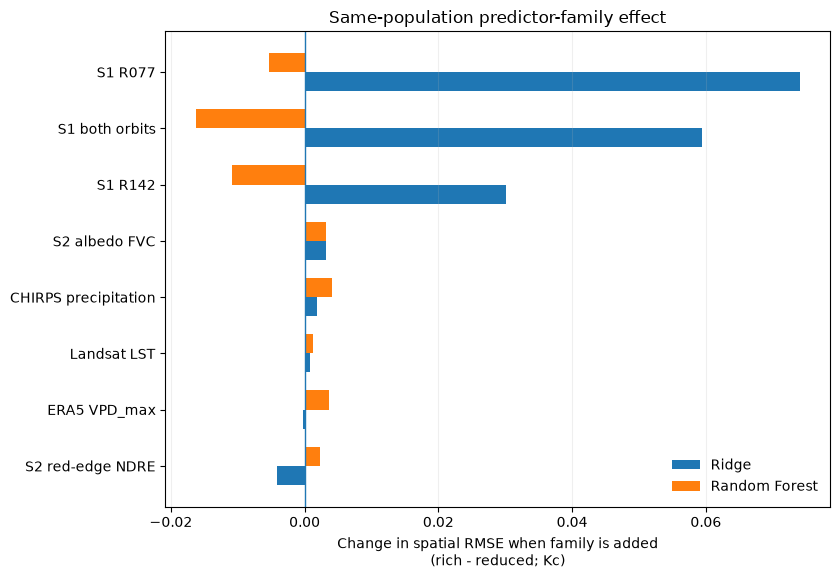

Saved: E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\scientific_figures_v1\D05_same_population_family_rmse_effect.png


,family,algorithm,n,rich_RMSE,reduced_RMSE,effect
0,CHIRPS precipitation,ridge,799,0.259484,0.257585,0.001899
2,CHIRPS precipitation,random_forest,799,0.282001,0.277931,0.004070
4,S2 red-edge NDRE,ridge,799,0.253458,0.257585,-0.004127
6,S2 red-edge NDRE,random_forest,799,0.280206,0.277931,0.002275
8,S2 albedo FVC,ridge,799,0.260799,0.257585,0.003213
10,S2 albedo FVC,random_forest,799,0.281150,0.277931,0.003219
12,ERA5 VPD_max,ridge,799,0.257318,0.257585,-0.000268
14,ERA5 VPD_max,random_forest,799,0.281636,0.277931,0.003705
16,Landsat LST,ridge,473,0.210695,0.209846,0.000849
18,Landsat LST,random_forest,473,0.242409,0.241157,0.001252


In [7]:
if FAMILY_EFFECTS is None:
    print("SKIP D05: family_same_population_effects.csv not found")
else:
    effects = pd.read_csv(FAMILY_EFFECTS)
    effects = effects.loc[effects["split_type"].astype(str).eq("spatial")].copy()
    effects["effect"] = pd.to_numeric(effects["rich_minus_reduced_RMSE"], errors="coerce")

    pivot = effects.pivot(index="family", columns="algorithm", values="effect")
    pivot = pivot.sort_values("ridge", na_position="last")

    y = np.arange(len(pivot))
    fig, ax = plt.subplots(figsize=(8.5, max(4.8, 0.55 * len(pivot) + 1.5)))
    width = 0.34
    if "ridge" in pivot.columns:
        ax.barh(y - width/2, pivot["ridge"], height=width, label="Ridge")
    if "random_forest" in pivot.columns:
        ax.barh(y + width/2, pivot["random_forest"], height=width, label="Random Forest")
    ax.axvline(0.0, linewidth=1.0)
    ax.set_yticks(y, pivot.index)
    ax.set_xlabel("Change in spatial RMSE when family is added\n(rich - reduced; Kc)")
    ax.set_title("Same-population predictor-family effect")
    ax.legend(frameon=False)
    ax.grid(axis="x", alpha=0.2)

    save_figure(fig, "D05_same_population_family_rmse_effect.png")
    display(effects[["family", "algorithm", "n", "rich_RMSE", "reduced_RMSE", "effect"]])


## D06 — Ridge versus Random Forest across availability rungs

Equivalente en propósito a F23. Esta figura conserva el rol de Random Forest como **análisis de sensibilidad**, no como segundo modelo operativo.

Las diferencias entre rungs no deben interpretarse causalmente porque algunos rungs usan poblaciones distintas. La comparación Ridge–RF *dentro* de cada rung sí usa la misma población.

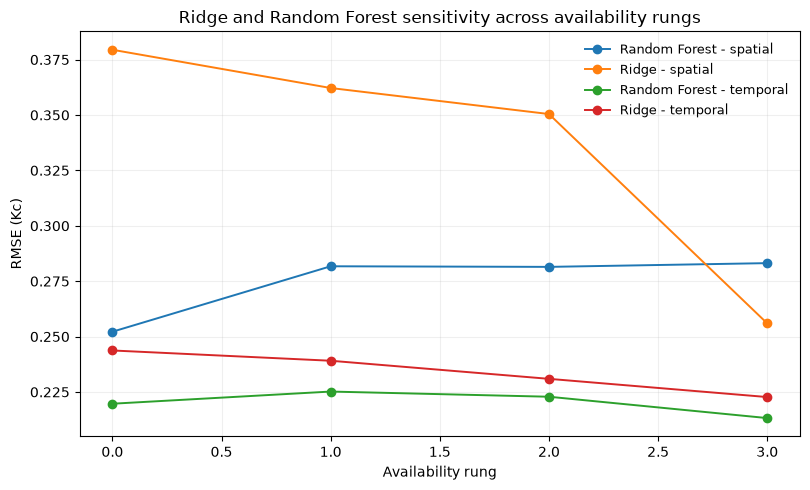

Saved: E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\scientific_figures_v1\D06_ridge_rf_availability_rungs.png


,rung,algorithm,split_type,n,RMSE,MAE,R2,KGE
80,0.0,random_forest,spatial,182,0.252184,0.195888,0.333332,0.425026
84,1.0,random_forest,spatial,346,0.281730,0.217204,0.299414,0.333832
88,2.0,random_forest,spatial,610,0.281460,0.210387,0.293864,0.300877
92,3.0,random_forest,spatial,799,0.283147,0.210233,0.226259,0.254531
82,0.0,ridge,spatial,182,0.379449,0.301636,-0.509320,0.433707
86,1.0,ridge,spatial,346,0.362184,0.286555,-0.157853,0.468208
90,2.0,ridge,spatial,610,0.350435,0.273952,-0.094633,0.478924
94,3.0,ridge,spatial,799,0.255949,0.190048,0.367765,0.485135
81,0.0,random_forest,temporal,182,0.219699,0.156135,0.494021,0.556987
85,1.0,random_forest,temporal,346,0.225193,0.162865,0.552386,0.607950


In [8]:
if AGGREGATE_SENSITIVITY is None:
    print("SKIP D06: aggregate_metrics.csv not found")
else:
    aggregate = pd.read_csv(AGGREGATE_SENSITIVITY)
    rung = aggregate.loc[
        aggregate["role"].astype(str).eq("availability_rung")
        & aggregate["algorithm"].astype(str).isin(["ridge", "random_forest"])
        & aggregate["split_type"].astype(str).isin(["spatial", "temporal"])
    ].copy()
    rung["rung"] = pd.to_numeric(rung["rung"], errors="coerce")
    rung = rung.dropna(subset=["rung"]).sort_values(["split_type", "algorithm", "rung"])

    fig, ax = plt.subplots(figsize=(8.2, 5.0))
    for (split_type, algorithm), group in rung.groupby(["split_type", "algorithm"], sort=True):
        label = f"{algorithm.replace('_', ' ').title()} - {split_type}"
        ax.plot(group["rung"], group["RMSE"], marker="o", linewidth=1.4, label=label)
    ax.set_xlabel("Availability rung")
    ax.set_ylabel("RMSE (Kc)")
    ax.set_title("Ridge and Random Forest sensitivity across availability rungs")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(alpha=0.2)

    save_figure(fig, "D06_ridge_rf_availability_rungs.png")
    display(rung[["rung", "algorithm", "split_type", "n", "RMSE", "MAE", "R2", "KGE"]])


## D07 — Exact-overlap reconciliation diagnostic at station pixels

Complementa F06. Compara ET antes y después de la proyección exact-overlap en los píxeles de las estaciones para la fecha diagnóstica. La conservación MODIS se evalúa globalmente en el QA; los puntos de estación se usan aquí solo para visualizar la magnitud local del ajuste.

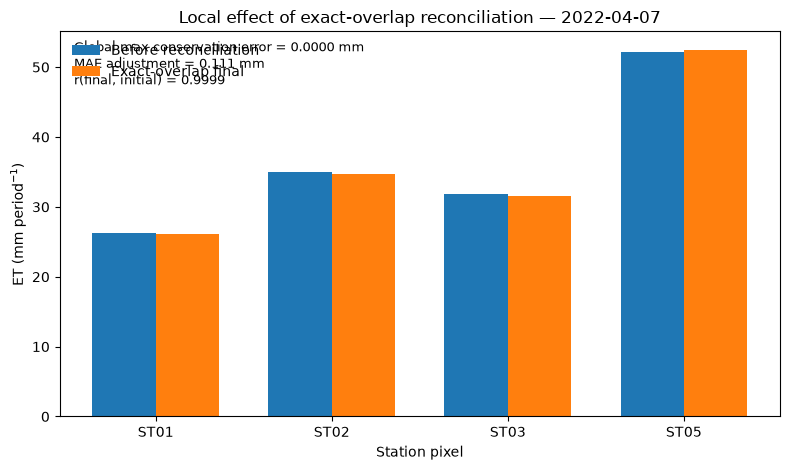

Saved: E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\scientific_figures_v1\D07_exact_overlap_station_adjustment.png


,station_id,ET_overlap_initial,ET_overlap_final,final_over_initial
0,ST01,26.200192,26.176110,0.999081
1,ST02,34.958643,34.766672,0.994509
2,ST03,31.791147,31.618819,0.994579
3,ST05,52.150692,52.493313,1.006570


In [9]:
if RECON_STATIONS is None:
    print("SKIP D07: stations_2022-04-07.csv not found")
else:
    recon = pd.read_csv(RECON_STATIONS)
    valid = recon.loc[
        recon["ET_overlap_initial"].notna() & recon["ET_overlap_final"].notna()
    ].copy()

    if valid.empty:
        print("SKIP D07: no valid initial/final station values")
    else:
        positions = np.arange(len(valid))
        width = 0.36
        fig, ax = plt.subplots(figsize=(8.0, 4.8))
        ax.bar(positions - width/2, valid["ET_overlap_initial"], width=width, label="Before reconciliation")
        ax.bar(positions + width/2, valid["ET_overlap_final"], width=width, label="Exact-overlap final")
        ax.set_xticks(positions, valid["station_id"].astype(str))
        ax.set_xlabel("Station pixel")
        ax.set_ylabel("ET (mm period$^{-1}$)")
        ax.set_title("Local effect of exact-overlap reconciliation — 2022-04-07")
        ax.legend(frameon=False)

        if RECON_SUMMARY is not None:
            summary = json.loads(RECON_SUMMARY.read_text(encoding="utf-8"))
            text = (
                f"Global max conservation error = "
                f"{summary.get('final_max_abs_modis_error_mm', np.nan):.4f} mm\n"
                f"MAE adjustment = {summary.get('mae_adjustment_mm', np.nan):.3f} mm\n"
                f"r(final, initial) = {summary.get('pearson_final_vs_initial', np.nan):.4f}"
            )
            ax.text(0.02, 0.98, text, transform=ax.transAxes, va="top", fontsize=9)

        save_figure(fig, "D07_exact_overlap_station_adjustment.png")
        display(valid[["station_id", "ET_overlap_initial", "ET_overlap_final", "final_over_initial"]])


## D08 — Final ET and AOA diagnostic maps for 2022-04-07

Muestra el producto final de ET junto con el dominio de aplicabilidad (`AOA_inside`). Es una figura diagnóstica de soporte espacial; no constituye validación independiente de la resolución de 20 m.

Raster bands: ['ET_mm_period', 'Kc_raw', 'dissimilarity_index', 'stack_valid', 'AOA_inside', 'usable', 'usable_fraction', 'coarse_eligible', 'ET_conservation_error_mm']


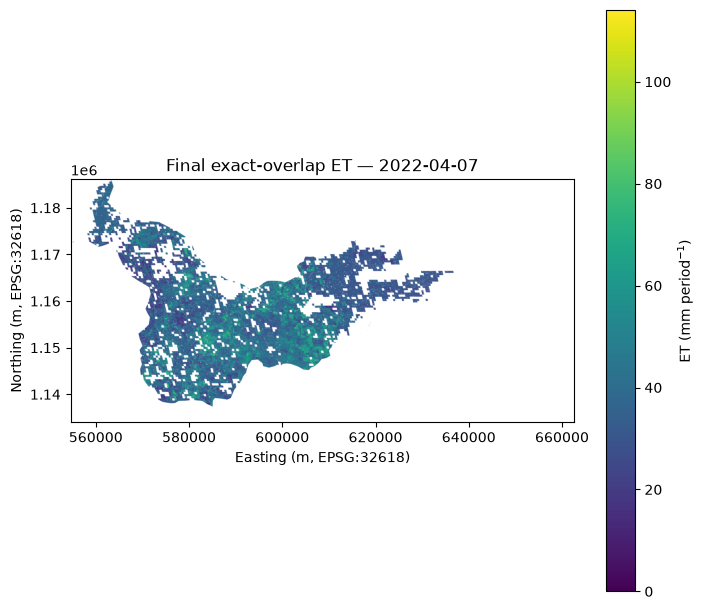

Saved: E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\scientific_figures_v1\D08a_final_et_map_20220407.png


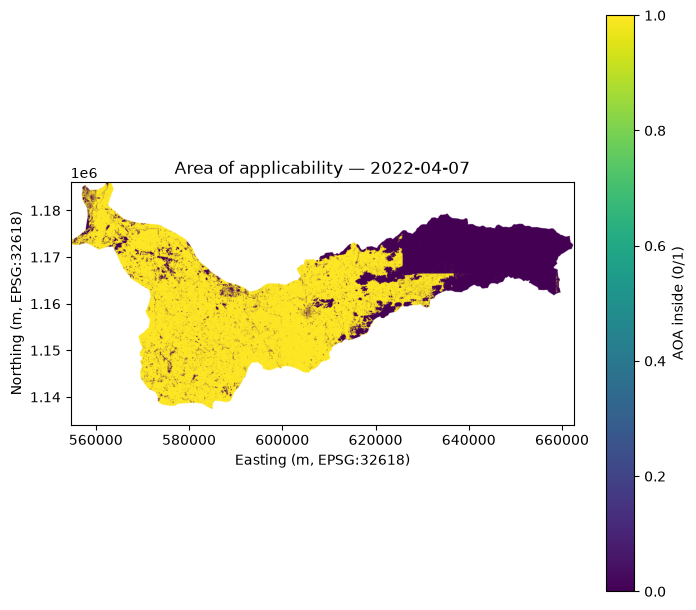

Saved: E:\1SIG22\Varios\github\git_github\ET_fundacion_workspace\current\diagnostics\scientific_figures_v1\D08b_aoa_map_20220407.png


In [10]:
if FINAL_RASTER is None:
    print("SKIP D08: final exact-overlap raster not found")
else:
    try:
        import rasterio
    except ImportError:
        print("SKIP D08: rasterio is not installed")
    else:
        with rasterio.open(FINAL_RASTER) as src:
            descriptions = list(src.descriptions)
            print("Raster bands:", descriptions)

            def read_band(name):
                if name not in descriptions:
                    raise KeyError(f"Band {name!r} not found")
                index = descriptions.index(name) + 1
                return src.read(index, masked=True), src.bounds

            et, bounds = read_band("ET_mm_period")
            aoa, _ = read_band("AOA_inside")

        extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

        fig, ax = plt.subplots(figsize=(7.2, 6.2))
        image = ax.imshow(et, extent=extent, origin="upper")
        fig.colorbar(image, ax=ax, label="ET (mm period$^{-1}$)")
        ax.set_xlabel("Easting (m, EPSG:32618)")
        ax.set_ylabel("Northing (m, EPSG:32618)")
        ax.set_title("Final exact-overlap ET — 2022-04-07")
        save_figure(fig, "D08a_final_et_map_20220407.png")

        fig, ax = plt.subplots(figsize=(7.2, 6.2))
        image = ax.imshow(aoa, extent=extent, origin="upper", vmin=0, vmax=1)
        fig.colorbar(image, ax=ax, label="AOA inside (0/1)")
        ax.set_xlabel("Easting (m, EPSG:32618)")
        ax.set_ylabel("Northing (m, EPSG:32618)")
        ax.set_title("Area of applicability — 2022-04-07")
        save_figure(fig, "D08b_aoa_map_20220407.png")


## Output inventory

Revisar estas figuras visual y científicamente antes de renombrarlas como Fxx o incorporarlas al manuscrito. En particular:

1. D03 debe conservar explícitamente la advertencia sobre el soporte de la comparación de campo.
2. D05 no debe interpretarse como causalidad o importancia independiente de variables.
3. D06 es sensibilidad metodológica; Random Forest no vuelve a ser modelo operativo.
4. D08 muestra una grilla de 20 m, no una validación independiente de ET a 20 m.

In [11]:
created = sorted(FIGURE_DIR.glob("D*.png"))
print(f"Created {len(created)} diagnostic figures")
for path in created:
    print(path.name)


Created 9 diagnostic figures
D01_fold_level_rmse.png
D02_spatial_oof_error_by_station.png
D03_field_et_comparison_fixed_kc.png
D04_predictor_availability_ladder.png
D05_same_population_family_rmse_effect.png
D06_ridge_rf_availability_rungs.png
D07_exact_overlap_station_adjustment.png
D08a_final_et_map_20220407.png
D08b_aoa_map_20220407.png


In [18]:
import pandas as pd

path = (
    r"E:\1SIG22\Varios\github\git_github"
    r"\ET_fundacion_workspace\current"
    r"\diagnostics\field_ridge25_oof_exact_overlap"
    r"\field_period_candidates.csv"
)

df = pd.read_csv(path)

print("Rows:", len(df))
print("\nColumns:")
print(df.columns.tolist())

for col in [
    "status",
    "publication_status",
    "analysis_role",
    "station_id",
    "inside_basin",
]:
    if col in df.columns:
        print(f"\n=== {col} ===")
        print(df[col].value_counts(dropna=False))

Rows: 60

Columns:
['station_id', 'station', 'period_start', 'number_days', 'n_valid_field_days', 'field_reference_eto_mm_period', 'Kc_field_conversion', 'Kc_source', 'analysis_role', 'field_derived_et_mm_period', 'ET_MODIS_mm_period', 'ETo_model_mm_period', 'NDVI_footprint_mean', 'inside_basin', 'installation_conforms_manual', 'longitude', 'latitude', 'spatial_block']

=== analysis_role ===
analysis_role
fixed_kc_main          35
ndvi_kc_sensitivity    22
excluded_invalid_kc     3
Name: count, dtype: int64

=== station_id ===
station_id
ST03    14
ST05    13
ST04    12
ST02    11
ST01    10
Name: count, dtype: int64

=== inside_basin ===
inside_basin
True     48
False    12
Name: count, dtype: int64


In [19]:
import pandas as pd
from pathlib import Path

root = Path(
    r"E:\1SIG22\Varios\github\git_github"
    r"\ET_fundacion_workspace\current"
    r"\diagnostics\field_ridge25_oof_exact_overlap"
)

candidates = pd.read_csv(
    root / "field_period_candidates.csv",
    parse_dates=["period_start"],
)

checkpoint = pd.read_csv(
    root / "field_ridge25_oof_checkpoint.csv",
    parse_dates=["period_start"],
)

pairs = pd.read_csv(
    root / "field_ridge25_oof_pairs.csv",
    parse_dates=["period_start"],
)

print("Candidates:", len(candidates))
print("Checkpoint:", len(checkpoint))
print("Pairs:", len(pairs))

print("\n=== CHECKPOINT COLUMNS ===")
print(checkpoint.columns.tolist())

for col in checkpoint.columns:
    if any(
        token in col.lower()
        for token in [
            "status",
            "publish",
            "eligible",
            "reason",
            "aoa",
            "support",
            "inside",
        ]
    ):
        print(f"\n=== {col} ===")
        print(checkpoint[col].value_counts(dropna=False))

print("\n=== PAIRS BY ANALYSIS ROLE ===")
if "analysis_role" in pairs.columns:
    print(pairs["analysis_role"].value_counts(dropna=False))

print("\n=== PAIRS BY STATION ===")
print(pairs["station_id"].value_counts(dropna=False))

Candidates: 60
Checkpoint: 60
Pairs: 60

=== CHECKPOINT COLUMNS ===
['station_id', 'station', 'period_start', 'number_days', 'n_valid_field_days', 'field_reference_eto_mm_period', 'Kc_field_conversion', 'Kc_source', 'analysis_role', 'field_derived_et_mm_period', 'ET_MODIS_mm_period', 'ETo_model_mm_period', 'NDVI_footprint_mean', 'inside_basin', 'installation_conforms_manual', 'longitude', 'latitude', 'spatial_block', 'ET_downscaled_oof_mm_period', 'production_status', 'evaluation_version', 'ET_mm_period', 'Kc_raw', 'dissimilarity_index', 'stack_valid', 'AOA_inside', 'usable', 'usable_fraction', 'coarse_eligible', 'ET_conservation_error_mm', 'pixel_row', 'pixel_col', 'tile_id', 'fold_training_rows', 'fold_test_rows', 'fold_oof_max_abs_difference', 'fold_aoa_threshold', 'support_rings', 'support_tile_count', 'eligible_modis_parents_local', 'negative_publishable_before_floor_local', 'max_abs_conservation_error_after_floor_mm_local', 'mae_adjustment_mm_local', 'rmse_adjustment_mm_local', '

In [20]:
# Diagnose why field periods were not published

check = checkpoint.copy()

cols = [
    "station_id",
    "period_start",
    "analysis_role",
    "production_status",
    "inside_basin",
    "stack_valid",
    "AOA_inside",
    "usable",
    "usable_fraction",
    "coarse_eligible",
    "Kc_raw",
]

print("=== STATUS BY STATION ===")
print(
    pd.crosstab(
        check["station_id"],
        check["production_status"],
        margins=True,
    )
)

print("\n=== STATUS BY ANALYSIS ROLE ===")
print(
    pd.crosstab(
        check["analysis_role"],
        check["production_status"],
        margins=True,
    )
)

print("\n=== NOT-PUBLISHED DIAGNOSTIC ===")

not_pub = check.loc[
    check["production_status"].eq("not_published"),
    cols,
].copy()

print("Rows:", len(not_pub))

for col in [
    "stack_valid",
    "AOA_inside",
    "usable",
    "coarse_eligible",
]:
    print(f"\n{col}:")
    print(not_pub[col].value_counts(dropna=False))

print("\nusable_fraction:")
print(not_pub["usable_fraction"].describe())

print("\nKc_raw:")
print(not_pub["Kc_raw"].describe())

print("\n=== PRIMARY EXCLUSION REASON ===")

def exclusion_reason(row):
    if not bool(row.get("inside_basin", False)):
        return "outside_basin"

    if pd.isna(row.get("AOA_inside")):
        return "no_evaluated_product"

    if row.get("stack_valid") in [False, 0]:
        return "invalid_predictor_stack"

    if row.get("AOA_inside") in [False, 0]:
        return "outside_AOA"

    if pd.notna(row.get("Kc_raw")) and row["Kc_raw"] < 0:
        return "negative_Kc"

    if row.get("coarse_eligible") in [False, 0]:
        return "coarse_support_below_90"

    if row.get("usable") in [False, 0]:
        return "fine_pixel_not_usable"

    return "other"

check["primary_reason"] = check.apply(exclusion_reason, axis=1)

print(
    check["primary_reason"]
    .value_counts(dropna=False)
)

print("\n=== REASON BY STATION ===")
print(
    pd.crosstab(
        check["station_id"],
        check["primary_reason"],
        margins=True,
    )
)

=== STATUS BY STATION ===
production_status  no_eligible_modis_parent  not_published  published  \
station_id                                                              
ST01                                      1              7          2   
ST02                                      1              5          5   
ST03                                      1             10          3   
ST04                                      0              0          0   
ST05                                      1              9          3   
All                                       4             31         13   

production_status  station_outside_basin  All  
station_id                                     
ST01                                   0   10  
ST02                                   0   11  
ST03                                   0   14  
ST04                                  12   12  
ST05                                   0   13  
All                                   12   60  

=== 

=== RAW PRE-RECONCILIATION AVAILABILITY ===
Field periods: 60
Field-derived ET available: 57
Raw fine OOF ET available: 36

=== RAW AVAILABLE BY STATION ===


ET_raw_oof_mm_period,No raw ET,Raw ET,All
station_id,,,
ST01,2,8,10
ST02,5,6,11
ST03,3,11,14
ST04,12,0,12
ST05,2,11,13
All,24,36,60



=== RAW AVAILABLE BY ANALYSIS ROLE ===


ET_raw_oof_mm_period,No raw ET,Raw ET,All
analysis_role,,,
excluded_invalid_kc,3,0,3
fixed_kc_main,10,25,35
ndvi_kc_sensitivity,11,11,22
All,24,36,60



=== PRE-RECONCILIATION FIELD METRICS ===


,comparison,n,R2,RMSE,MAE,Bias,Pearson_r
0,All valid field references: MODIS,36,-1.521,11.614,9.558,5.002,0.032
1,All valid field references: raw Ridge25 OOF,36,-0.589,9.222,7.491,2.728,-0.166
2,Fixed-Kc main: MODIS,25,-0.327,9.143,7.265,0.705,0.210
3,Fixed-Kc main: raw Ridge25 OOF,25,-0.644,10.176,8.441,2.619,-0.538
4,NDVI-Kc sensitivity: MODIS,11,-11.299,15.857,14.769,14.769,0.379
5,NDVI-Kc sensitivity: raw Ridge25 OOF,11,-1.103,6.557,5.332,2.977,0.139



=== RAW VS RECONCILED — IDENTICAL FIELD SAMPLE ===


,comparison,n,R2,RMSE,MAE,Bias,Pearson_r
0,MODIS — same final sample,10,-0.060,9.034,6.910,0.821,0.333
1,Raw Ridge25 OOF — same final sample,10,-0.379,10.305,8.741,2.714,-0.335
2,Exact-overlap Ridge25 OOF — same final sample,10,0.006,8.746,7.436,-1.515,0.352



=== RAW SAMPLE BY STATION AND ROLE ===


,station_id,analysis_role,n
0,ST01,fixed_kc_main,8
1,ST02,fixed_kc_main,6
2,ST03,fixed_kc_main,11
3,ST05,ndvi_kc_sensitivity,11


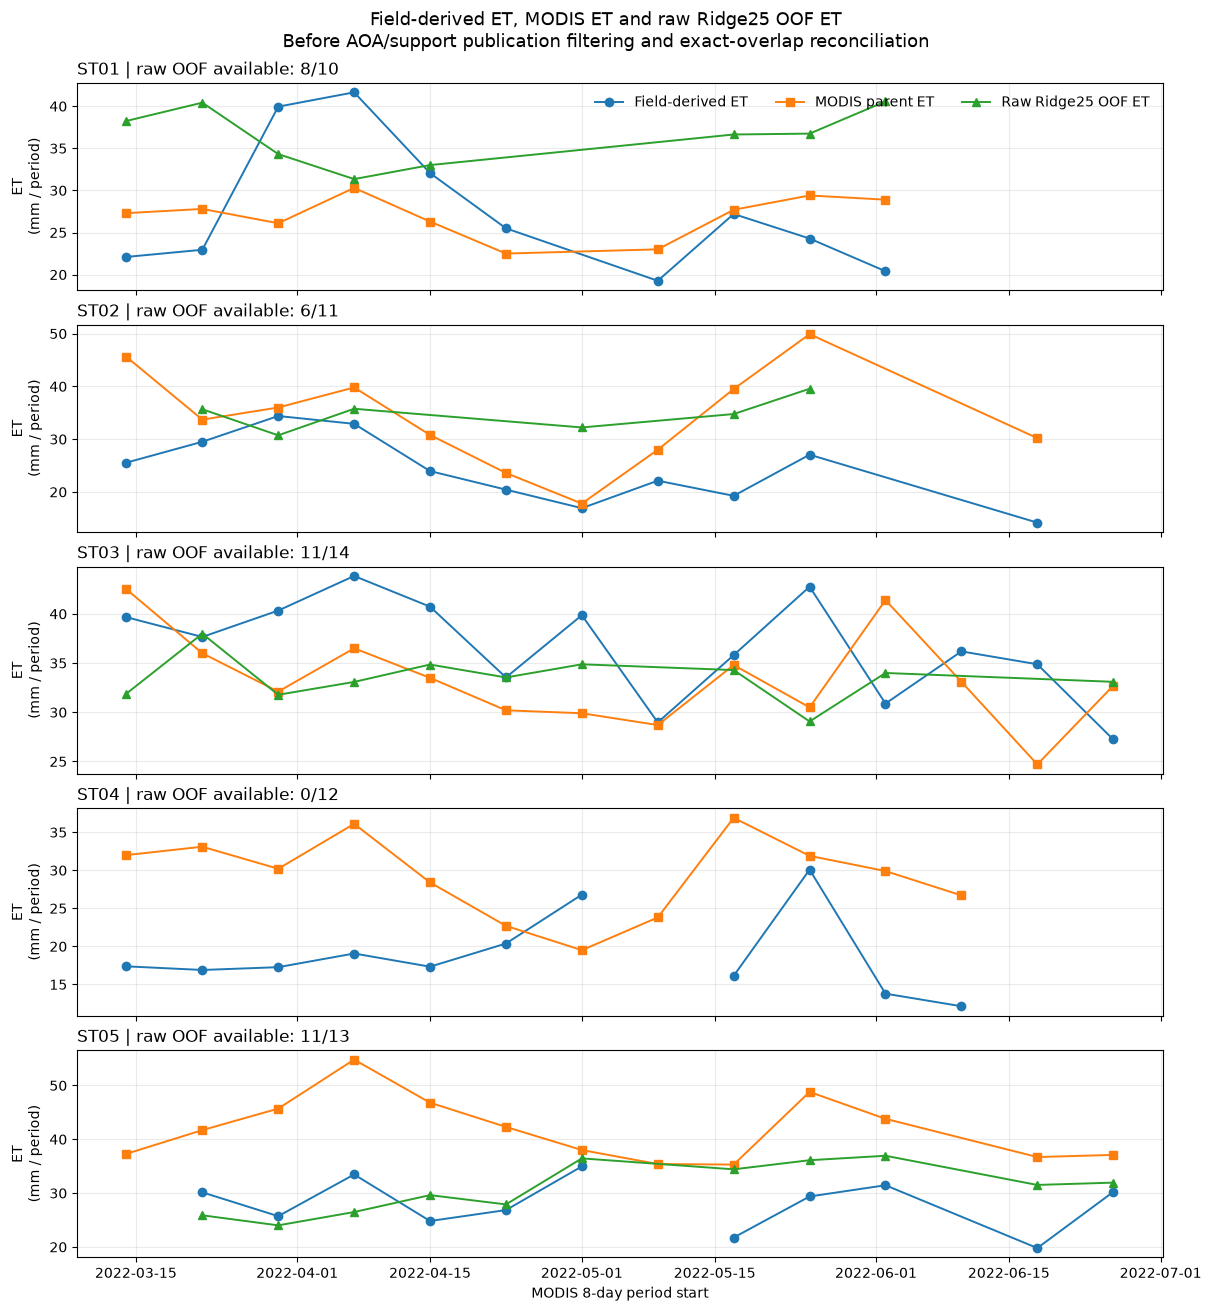

In [22]:
# Pre-reconciliation field comparison using existing raw Ridge25 predictions.
# This cell only reads existing diagnostics and creates no files.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)

# ---------------------------------------------------------------------
# Load current exact-overlap field checkpoint
# ---------------------------------------------------------------------

workspace = Path(
    r"E:\1SIG22\Varios\github\git_github"
    r"\ET_fundacion_workspace\current"
)

field_root = (
    workspace
    / "diagnostics"
    / "field_ridge25_oof_exact_overlap"
)

checkpoint = pd.read_csv(
    field_root / "field_ridge25_oof_checkpoint.csv",
    parse_dates=["period_start"],
)

# ---------------------------------------------------------------------
# Reconstruct raw fine ET BEFORE exact-overlap reconciliation
# ---------------------------------------------------------------------

checkpoint["ET_raw_oof_mm_period"] = (
    checkpoint["Kc_raw"]
    * checkpoint["ETo_model_mm_period"]
)

checkpoint["raw_available"] = (
    checkpoint["field_derived_et_mm_period"].notna()
    & checkpoint["ET_raw_oof_mm_period"].notna()
)

print("=== RAW PRE-RECONCILIATION AVAILABILITY ===")
print("Field periods:", len(checkpoint))

print(
    "Field-derived ET available:",
    checkpoint["field_derived_et_mm_period"].notna().sum(),
)

print(
    "Raw fine OOF ET available:",
    checkpoint["ET_raw_oof_mm_period"].notna().sum(),
)

print("\n=== RAW AVAILABLE BY STATION ===")

station_availability = pd.crosstab(
    checkpoint["station_id"],
    checkpoint["ET_raw_oof_mm_period"].notna(),
    margins=True,
)

station_availability = station_availability.rename(
    columns={
        False: "No raw ET",
        True: "Raw ET",
    }
)

display(station_availability)

print("\n=== RAW AVAILABLE BY ANALYSIS ROLE ===")

role_availability = pd.crosstab(
    checkpoint["analysis_role"],
    checkpoint["ET_raw_oof_mm_period"].notna(),
    margins=True,
)

role_availability = role_availability.rename(
    columns={
        False: "No raw ET",
        True: "Raw ET",
    }
)

display(role_availability)


# ---------------------------------------------------------------------
# Metric helper
# ---------------------------------------------------------------------

def calculate_metrics(data, prediction_col, label):
    matched = data[
        [
            "field_derived_et_mm_period",
            prediction_col,
        ]
    ].dropna()

    if len(matched) < 2:
        return {
            "comparison": label,
            "n": len(matched),
            "R2": np.nan,
            "RMSE": np.nan,
            "MAE": np.nan,
            "Bias": np.nan,
            "Pearson_r": np.nan,
        }

    observed = matched["field_derived_et_mm_period"].to_numpy()
    predicted = matched[prediction_col].to_numpy()

    return {
        "comparison": label,
        "n": len(matched),
        "R2": r2_score(observed, predicted),
        "RMSE": np.sqrt(
            mean_squared_error(
                observed,
                predicted,
            )
        ),
        "MAE": mean_absolute_error(
            observed,
            predicted,
        ),
        "Bias": np.mean(
            predicted - observed
        ),
        "Pearson_r": np.corrcoef(
            observed,
            predicted,
        )[0, 1],
    }


# ---------------------------------------------------------------------
# Maximum valid field-reference sample with raw prediction
# ---------------------------------------------------------------------

all_valid = checkpoint[
    checkpoint["analysis_role"].ne("excluded_invalid_kc")
].copy()

all_valid_matched = all_valid[
    all_valid["ET_raw_oof_mm_period"].notna()
].copy()


# ---------------------------------------------------------------------
# Main fixed-Kc reference
# ---------------------------------------------------------------------

fixed_main = checkpoint[
    checkpoint["analysis_role"].eq("fixed_kc_main")
].copy()

fixed_main_matched = fixed_main[
    fixed_main["ET_raw_oof_mm_period"].notna()
].copy()


# ---------------------------------------------------------------------
# NDVI-Kc sensitivity
# ---------------------------------------------------------------------

sensitivity = checkpoint[
    checkpoint["analysis_role"].eq("ndvi_kc_sensitivity")
].copy()

sensitivity_matched = sensitivity[
    sensitivity["ET_raw_oof_mm_period"].notna()
].copy()


# ---------------------------------------------------------------------
# Metrics: MODIS and raw Ridge25 on the SAME rows
# ---------------------------------------------------------------------

metric_rows = []

for subset_name, subset in [
    (
        "All valid field references",
        all_valid_matched,
    ),
    (
        "Fixed-Kc main",
        fixed_main_matched,
    ),
    (
        "NDVI-Kc sensitivity",
        sensitivity_matched,
    ),
]:
    metric_rows.append(
        calculate_metrics(
            subset,
            "ET_MODIS_mm_period",
            f"{subset_name}: MODIS",
        )
    )

    metric_rows.append(
        calculate_metrics(
            subset,
            "ET_raw_oof_mm_period",
            f"{subset_name}: raw Ridge25 OOF",
        )
    )

metrics = pd.DataFrame(metric_rows)

metric_cols = [
    "R2",
    "RMSE",
    "MAE",
    "Bias",
    "Pearson_r",
]

metrics_display = metrics.copy()

for col in metric_cols:
    metrics_display[col] = (
        metrics_display[col]
        .round(3)
    )

print("\n=== PRE-RECONCILIATION FIELD METRICS ===")
display(metrics_display)


# ---------------------------------------------------------------------
# Raw vs reconciled comparison on IDENTICAL rows
# ---------------------------------------------------------------------

if "ET_downscaled_oof_mm_period" in checkpoint.columns:

    same_final = checkpoint[
        checkpoint["analysis_role"].eq("fixed_kc_main")
        & checkpoint["ET_raw_oof_mm_period"].notna()
        & checkpoint["ET_downscaled_oof_mm_period"].notna()
        & checkpoint["field_derived_et_mm_period"].notna()
    ].copy()

    comparison_rows = [
        calculate_metrics(
            same_final,
            "ET_MODIS_mm_period",
            "MODIS — same final sample",
        ),
        calculate_metrics(
            same_final,
            "ET_raw_oof_mm_period",
            "Raw Ridge25 OOF — same final sample",
        ),
        calculate_metrics(
            same_final,
            "ET_downscaled_oof_mm_period",
            "Exact-overlap Ridge25 OOF — same final sample",
        ),
    ]

    comparison_df = pd.DataFrame(
        comparison_rows
    )

    comparison_display = (
        comparison_df.copy()
    )

    for col in metric_cols:
        comparison_display[col] = (
            comparison_display[col]
            .round(3)
        )

    print(
        "\n=== RAW VS RECONCILED — IDENTICAL FIELD SAMPLE ==="
    )

    display(comparison_display)


# ---------------------------------------------------------------------
# Additional diagnostic: sample size by station
# ---------------------------------------------------------------------

print("\n=== RAW SAMPLE BY STATION AND ROLE ===")

sample_summary = (
    checkpoint[
        checkpoint["ET_raw_oof_mm_period"].notna()
    ]
    .groupby(
        [
            "station_id",
            "analysis_role",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="n")
)

display(sample_summary)


# ---------------------------------------------------------------------
# Temporal comparison across all five stations
# ---------------------------------------------------------------------

station_order = [
    "ST01",
    "ST02",
    "ST03",
    "ST04",
    "ST05",
]

fig, axes = plt.subplots(
    5,
    1,
    figsize=(12, 13),
    sharex=True,
    constrained_layout=True,
)

for ax, station_id in zip(
    axes,
    station_order,
):

    station = (
        checkpoint[
            checkpoint["station_id"].eq(
                station_id
            )
        ]
        .sort_values("period_start")
        .copy()
    )

    ax.plot(
        station["period_start"],
        station[
            "field_derived_et_mm_period"
        ],
        marker="o",
        linewidth=1.4,
        label="Field-derived ET",
    )

    ax.plot(
        station["period_start"],
        station[
            "ET_MODIS_mm_period"
        ],
        marker="s",
        linewidth=1.4,
        label="MODIS parent ET",
    )

    raw = station[
        station[
            "ET_raw_oof_mm_period"
        ].notna()
    ]

    if len(raw):
        ax.plot(
            raw["period_start"],
            raw[
                "ET_raw_oof_mm_period"
            ],
            marker="^",
            linewidth=1.4,
            label="Raw Ridge25 OOF ET",
        )

    n_raw = (
        station[
            "ET_raw_oof_mm_period"
        ]
        .notna()
        .sum()
    )

    ax.set_title(
        (
            f"{station_id} | "
            f"raw OOF available: "
            f"{n_raw}/{len(station)}"
        ),
        loc="left",
    )

    ax.set_ylabel(
        "ET\n(mm / period)"
    )

    ax.grid(
        alpha=0.25
    )

axes[0].legend(
    frameon=False,
    ncol=3,
    loc="upper right",
)

axes[-1].set_xlabel(
    "MODIS 8-day period start"
)

fig.suptitle(
    (
        "Field-derived ET, MODIS ET and raw Ridge25 OOF ET\n"
        "Before AOA/support publication filtering and "
        "exact-overlap reconciliation"
    ),
    fontsize=13,
)

plt.show()